In [71]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
case = pd.read_csv('data/Case.csv')                      # 코로나 확진자들이 나온 장소의 정확한 위치(위도에 경도까지...)
patient_info = pd.read_csv('data/PatientInfo.csv')       # 나이, 성별 별로 분석할 수 있을 듯
policy = pd.read_csv('data/Policy.csv')                 # 우리나라 코로나 이후 여러가지 정책
region = pd.read_csv('data/Region.csv')                 # 지역별 인원 분포
search_trend = pd.read_csv('data/SearchTrend.csv')      # 검색 트랜드 ( 코로나를 얼마나 검색해봤는가)
seoul_floating = pd.read_csv('data/SeoulFloating.csv') 
time = pd.read_csv('data/Time.csv')                     # 일별 확진자, 사상자 수 (치사율 확인할 수 있을듯)
time_age = pd.read_csv('data/TimeAge.csv')              # 연령별 확진자, 사상자 수 (나이별 치사율 확인할 수 있을듯)
time_gender = pd.read_csv('data/TimeGender.csv')        # 성별 확진자, 사상자 수 (남,여 치사율 확인할 수 있을듯)
time_province = pd.read_csv('data/TimeProvince.csv')    
weather = pd.read_csv('data/Weather.csv')

# Idea 1 : 20-30대 확진자는 어느 구에서 많이 나오는가?

In [118]:
patient_info

,patient_id,sex,age,country,province,city
0,1000000001,male,50s,Korea,Seoul,Gangseo-gu
1,1000000002,male,30s,Korea,Seoul,Jungnang-gu
2,1000000003,male,50s,Korea,Seoul,Jongno-gu
3,1000000004,male,20s,Korea,Seoul,Mapo-gu
4,1000000005,female,20s,Korea,Seoul,Seongbuk-gu
...,...,...,...,...,...,...
5160,7000000015,female,30s,Korea,Jeju-do,Jeju-do
5161,7000000016,NaN,NaN,Korea,Jeju-do,Jeju-do
5162,7000000017,NaN,NaN,Bangladesh,Jeju-do,Jeju-do
5163,7000000018,NaN,NaN,Bangladesh,Jeju-do,Jeju-do


In [74]:
patient_info.columns

Index(['patient_id', 'sex', 'age', 'country', 'province', 'city',
       'infection_case', 'infected_by', 'contact_number', 'symptom_onset_date',
       'confirmed_date', 'released_date', 'deceased_date', 'state'],
      dtype='object')

In [75]:
patient_info.drop(['infection_case', 'infected_by', 'contact_number', 'symptom_onset_date', 'confirmed_date', 'released_date', 'deceased_date', 'state'], axis=1, inplace=True)
patient_info

,patient_id,sex,age,country,province,city
0,1000000001,male,50s,Korea,Seoul,Gangseo-gu
1,1000000002,male,30s,Korea,Seoul,Jungnang-gu
2,1000000003,male,50s,Korea,Seoul,Jongno-gu
3,1000000004,male,20s,Korea,Seoul,Mapo-gu
4,1000000005,female,20s,Korea,Seoul,Seongbuk-gu
...,...,...,...,...,...,...
5160,7000000015,female,30s,Korea,Jeju-do,Jeju-do
5161,7000000016,NaN,NaN,Korea,Jeju-do,Jeju-do
5162,7000000017,NaN,NaN,Bangladesh,Jeju-do,Jeju-do
5163,7000000018,NaN,NaN,Bangladesh,Jeju-do,Jeju-do


In [76]:
patient_info['country']

0            Korea
1            Korea
2            Korea
3            Korea
4            Korea
           ...    
5160         Korea
5161         Korea
5162    Bangladesh
5163    Bangladesh
5164    Bangladesh
Name: country, Length: 5165, dtype: object

In [77]:
patient_info.isnull()

,patient_id,sex,age,country,province,city
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
5160,False,False,False,False,False,False
5161,False,True,True,False,False,False
5162,False,True,True,False,False,False
5163,False,True,True,False,False,False


In [78]:
patient_info_dropped = patient_info.dropna(axis=0)
patient_info_dropped

,patient_id,sex,age,country,province,city
0,1000000001,male,50s,Korea,Seoul,Gangseo-gu
1,1000000002,male,30s,Korea,Seoul,Jungnang-gu
2,1000000003,male,50s,Korea,Seoul,Jongno-gu
3,1000000004,male,20s,Korea,Seoul,Mapo-gu
4,1000000005,female,20s,Korea,Seoul,Seongbuk-gu
...,...,...,...,...,...,...
5156,7000000011,male,30s,Korea,Jeju-do,Jeju-do
5157,7000000012,female,20s,Korea,Jeju-do,Jeju-do
5158,7000000013,female,10s,China,Jeju-do,Jeju-do
5159,7000000014,female,30s,Korea,Jeju-do,Jeju-do


In [79]:
Korea = patient_info[patient_info.country == 'Korea']
Korea

,patient_id,sex,age,country,province,city
0,1000000001,male,50s,Korea,Seoul,Gangseo-gu
1,1000000002,male,30s,Korea,Seoul,Jungnang-gu
2,1000000003,male,50s,Korea,Seoul,Jongno-gu
3,1000000004,male,20s,Korea,Seoul,Mapo-gu
4,1000000005,female,20s,Korea,Seoul,Seongbuk-gu
...,...,...,...,...,...,...
5156,7000000011,male,30s,Korea,Jeju-do,Jeju-do
5157,7000000012,female,20s,Korea,Jeju-do,Jeju-do
5159,7000000014,female,30s,Korea,Jeju-do,Jeju-do
5160,7000000015,female,30s,Korea,Jeju-do,Jeju-do


In [80]:
age_20 = patient_info_dropped[patient_info_dropped.age == '20s']
age_20

,patient_id,sex,age,country,province,city
3,1000000004,male,20s,Korea,Seoul,Mapo-gu
4,1000000005,female,20s,Korea,Seoul,Seongbuk-gu
6,1000000007,male,20s,Korea,Seoul,Jongno-gu
7,1000000008,male,20s,Korea,Seoul,etc
11,1000000012,male,20s,Korea,Seoul,etc
...,...,...,...,...,...,...
5150,7000000005,female,20s,Korea,Jeju-do,Jeju-do
5152,7000000007,female,20s,Korea,Jeju-do,Jeju-do
5154,7000000009,female,20s,Korea,Jeju-do,Jeju-do
5155,7000000010,female,20s,Korea,Jeju-do,Jeju-do


In [81]:
age_30 = patient_info_dropped[patient_info_dropped.age == '30s']
age_30

,patient_id,sex,age,country,province,city
1,1000000002,male,30s,Korea,Seoul,Jungnang-gu
8,1000000009,male,30s,Korea,Seoul,Songpa-gu
21,1000000022,male,30s,Korea,Seoul,Seodaemun-gu
25,1000000026,male,30s,Korea,Seoul,Seocho-gu
34,1000000035,male,30s,Korea,Seoul,etc
...,...,...,...,...,...,...
5145,6100000133,male,30s,Korea,Gyeongsangnam-do,Yangsan-si
5151,7000000006,male,30s,United States,Jeju-do,Jeju-do
5156,7000000011,male,30s,Korea,Jeju-do,Jeju-do
5159,7000000014,female,30s,Korea,Jeju-do,Jeju-do


In [112]:
age_20_30 = age_20.append(age_30)
age_20_30

,patient_id,sex,age,country,province,city
3,1000000004,male,20s,Korea,Seoul,Mapo-gu
4,1000000005,female,20s,Korea,Seoul,Seongbuk-gu
6,1000000007,male,20s,Korea,Seoul,Jongno-gu
7,1000000008,male,20s,Korea,Seoul,etc
11,1000000012,male,20s,Korea,Seoul,etc
...,...,...,...,...,...,...
5145,6100000133,male,30s,Korea,Gyeongsangnam-do,Yangsan-si
5151,7000000006,male,30s,United States,Jeju-do,Jeju-do
5156,7000000011,male,30s,Korea,Jeju-do,Jeju-do
5159,7000000014,female,30s,Korea,Jeju-do,Jeju-do


In [100]:
cities = []
for i in age_20_30['city']:
    cities.append(i)

cities

['Mapo-gu',
 'Seongbuk-gu',
 'Jongno-gu',
 'etc',
 'etc',
 'etc',
 'Jongno-gu',
 'Songpa-gu',
 'Songpa-gu',
 'etc',
 'Gangnam-gu',
 'Eunpyeong-gu',
 'Gwanak-gu',
 'Songpa-gu',
 'Yangcheon-gu',
 'Songpa-gu',
 'Gangnam-gu',
 'Seongdong-gu',
 'Nowon-gu',
 'Songpa-gu',
 'Songpa-gu',
 'Yeongdeungpo-gu',
 'Seongbuk-gu',
 'Dongdaemun-gu',
 'Dongdaemun-gu',
 'Yangcheon-gu',
 'Dongdaemun-gu',
 'Dongdaemun-gu',
 'Dongdaemun-gu',
 'Dongjak-gu',
 'Guro-gu',
 'Dongdaemun-gu',
 'Gangseo-gu',
 'Dongdaemun-gu',
 'Dongdaemun-gu',
 'Dongdaemun-gu',
 'Gwanak-gu',
 'Gwanak-gu',
 'Gangseo-gu',
 'Gangseo-gu',
 'Seodaemun-gu',
 'Dongdaemun-gu',
 'Dongdaemun-gu',
 'Mapo-gu',
 'Seongbuk-gu',
 'Gangnam-gu',
 'Seongbuk-gu',
 'Geumcheon-gu',
 'Gwanak-gu',
 'Gwanak-gu',
 'Seocho-gu',
 'Seocho-gu',
 'Nowon-gu',
 'Mapo-gu',
 'Dongdaemun-gu',
 'Mapo-gu',
 'Nowon-gu',
 'Eunpyeong-gu',
 'Dongdaemun-gu',
 'Dongdaemun-gu',
 'Yeongdeungpo-gu',
 'Songpa-gu',
 'etc',
 'Mapo-gu',
 'Nowon-gu',
 'Dongjak-gu',
 'Yeongdeungpo-gu

In [103]:
dup_cities = list(set(cities))

In [104]:
city_count = {}
for city in dup_cities:
    city_count[city] = 0
    
for city in cities:
    city_count[city] += 1
    
city_count

{'Yeosu-si': 3,
 'Yeonsu-gu': 5,
 'Osan-si': 5,
 'Dong-gu': 12,
 'Chuncheon-si': 6,
 'Seocho-gu': 18,
 'Hamyang-gun': 1,
 'Namdong-gu': 9,
 'Eunpyeong-gu': 9,
 'Namyangju-si': 10,
 'Jeonju-si': 7,
 'Hapcheon-gun': 4,
 'Michuhol-gu': 4,
 'Sejong': 10,
 'Mokpo-si': 1,
 'Sangju-si': 4,
 'Jungnang-gu': 9,
 'Jung-gu': 14,
 'Yuseong-gu': 10,
 'etc': 26,
 'Seongbuk-gu': 11,
 'Bonghwa-gun': 2,
 'Gapyeong-gun': 1,
 'Daedeok-gu': 3,
 'Seongdong-gu': 2,
 'Eumseong-gun': 1,
 'Suwon-si': 29,
 'Paju-si': 4,
 'Gangneung-si': 5,
 'Dongjak-gu': 14,
 'Namhae-gun': 1,
 'Changnyeong-gun': 5,
 'Yongin-si': 45,
 'Saha-gu': 6,
 'Nam-gu': 18,
 'Suncheon-si': 1,
 'Gimpo-si': 15,
 'Gwanak-gu': 17,
 'Buk-gu': 10,
 'Pohang-si': 37,
 'Gumi-si': 37,
 'Dongnae-gu': 13,
 'Mapo-gu': 12,
 'Icheon-dong': 1,
 'Chilgok-gun': 19,
 'Uiwang-si': 3,
 'Chungju-si': 6,
 'Guri-si': 2,
 'Anseong-si': 1,
 'Gimcheon-si': 11,
 'Seodaemun-gu': 10,
 'Gimhae-si': 8,
 'Miryang-si': 2,
 'Gyeyang-gu': 2,
 'Gangseo-gu': 15,
 'Haeundae-gu':

In [108]:
x = list(city_count.keys())
y = list(city_count.values())

<BarContainer object of 142 artists>

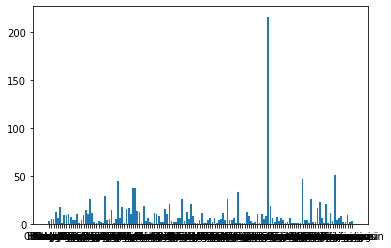

In [114]:
plt.bar(x=x, height=y)

In [126]:
final = pd.DataFrame(city_count.items(), columns = ['city','count'])
final

,city,count
0,Yeosu-si,3
1,Yeonsu-gu,5
2,Osan-si,5
3,Dong-gu,12
4,Chuncheon-si,6
...,...,...
137,Sasang-gu,2
138,Yeongju-si,2
139,Uijeongbu-si,9
140,Sacheon-si,2


<AxesSubplot:xlabel='count', ylabel='city'>

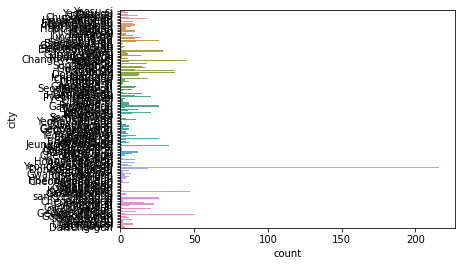

In [128]:
sns.barplot(data = final, x= 'count', y='city')